In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



In [29]:
df = pd.read_csv('/content/housing.csv')
print(df.shape)
df.head(10)

(489, 4)


,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0
5,6.430,5.21,18.7,602700.0
6,6.012,12.43,15.2,480900.0
7,6.172,19.15,15.2,569100.0
8,5.631,29.93,15.2,346500.0
9,6.004,17.10,15.2,396900.0


In [30]:
X = df.drop(columns='MEDV')
Y = df[['MEDV']]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [53]:


model = LinearRegression()

model.fit(X_train_scaled, Y_train)

y_pred = model.predict(X_test_scaled)

In [54]:
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(Y_test, y_pred)
print(r2)

mse = mean_squared_error(Y_test, y_pred)
print(mse)

rmse = np.sqrt(mse)
print(rmse)

0.6910934003098512
6789025559.265888
82395.54332162565


In [55]:
test_feature_vector = pd.DataFrame([[7.575,4.98,13.3]], columns=['RM', 'LSTAT', 'PTRATIO'])
test_feature_vector_scaled = scaler.transform(test_feature_vector)
print(model.predict(test_feature_vector_scaled))

[[759587.91580581]]


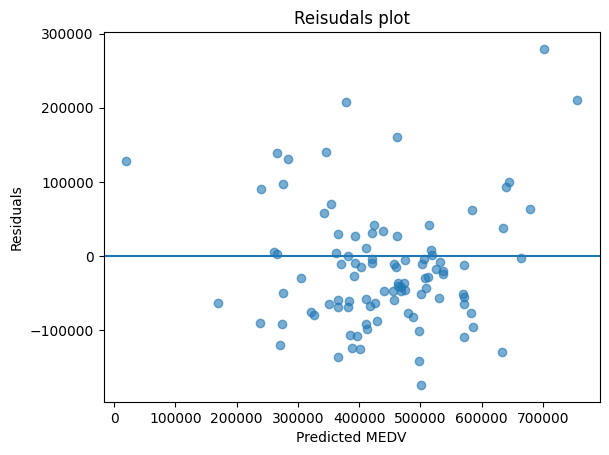

In [57]:
residuals = Y_test - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted MEDV")
plt.ylabel('Residuals')
plt.title('Resiudals plot')
plt.show()